![Banner](../../images/03_banner.png)


# 3.2 OLS Baseline and Diagnostics

**Part:** 3 — Spatial Regression (Chapter 3.2 of 7)

**Dataset:** `diabetes_atlantic.shp` (666 counties)

**Focus:** Fitting the OLS baseline, information criteria, classical diagnostics, and residual spatial autocorrelation

**Library:** `spatialstats.regression` (PySpatialStats)

***

## Table of Contents

1. [Overview](#1.-Overview)

2. [Python Setup](#2.-Python-Setup)

3. [Fitting the OLS Baseline](#3.-Fitting-the-OLS-Baseline)

4. [Information Criteria and Comparability](#4.-Information-Criteria-and-Comparability)

5. [Classical Diagnostics](#5.-Classical-Diagnostics)

6. [Residual Spatial Autocorrelation](#6.-Residual-Spatial-Autocorrelation)

7. [Summary and Conclusions](#7.-Summary-and-Conclusions)

8. [Resources](#8.-Resources)


***
## 1. Overview

Every spatial model in this Part is judged against, and often built directly from, the OLS fit constructed
here. This chapter has one job: fit that baseline carefully, and run every diagnostic that Chapter 3.3 needs as
input.

| Step | What we do |
|------|------------|
| Fit | `OLS(y, X, w=w)` on the Part 3.1 dataset, and read the coefficient table |
| Information criteria | Explain exactly what AIC/BIC count here, so they stay comparable across every model in Chapters 3.4–3.5 |
| Classical diagnostics | Condition number (multicollinearity), Jarque–Bera (normality), Breusch–Pagan (heteroskedasticity) |
| Spatial diagnostic | `residual_moran()` — the bridge back to Part 2, and the central question this whole Part exists to answer |

The residual Moran's I computed at the end of this chapter is the number Chapter 3.3's formal tests are built
to explain, and the number every later model (Chapter 3.5) is judged by how far it drives toward zero.

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.weights import Queen
from spatialstats.esda import Moran
from spatialstats.viz import moran_scatter, choropleth
from spatialstats.regression import OLS

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
     "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}

counties = gpd.read_file(DATA / "diabetes_atlantic.shp")
covariates = ["Obesity", "PhysInact", "Acc_Exer", "PCP_rate", "FoodEnvIdx", "SVI"]
X = counties[covariates].copy()
X["Urban"] = (counties["UrbRural"] == "Urban").astype(int)
y = counties["Dia_pct"]
w = Queen(counties)
print(f"spatialstats : version {spatialstats.__version__}")
print(f"n={len(counties)}, k={X.shape[1] + 1} (incl. intercept), islands={len(w.islands())}")

spatialstats : version 0.2.0
n=666, k=8 (incl. intercept), islands=0


***
## 3. Fitting the OLS Baseline

`OLS(y, X, w=w)` adds an intercept automatically and, because `w` is supplied, unlocks `lm_tests()` and
`residual_moran()` later without needing to pass `w` again.

In [2]:
ols = OLS(y, X, w=w)
print(ols.summary())

Ordinary Least Squares   (dependent variable: Dia_pct)
  Observations      666    Log likelihood    -784.2015
  Parameters          8    AIC               1584.4029
  Pseudo R²      0.7470    BIC               1620.4133

  variable                 coef    std err        t         p
  const                  3.1546     0.4362    7.233    0.0000 ***
  Obesity                0.1462     0.0112   13.093    0.0000 ***
  PhysInact              0.1520     0.0147   10.368    0.0000 ***
  Acc_Exer              -0.0060     0.0016   -3.718    0.0002 ***
  PCP_rate              -0.0003     0.0009   -0.368    0.7129 
  FoodEnvIdx            -0.2002     0.0458   -4.368    0.0000 ***
  SVI                    1.0327     0.1684    6.134    0.0000 ***
  Urban                 -0.0144     0.0748   -0.193    0.8472 

  R² = 0.7470   adj. R² = 0.7443   σ² = 0.6245

Diagnostics
-----------
                        diagnostic     value      p_value
Multicollinearity condition number 48.075084          NaN
      

Every covariate except primary-care access (`PCP_rate`) and the urban/rural indicator (`Urban`) is significant
at conventional levels; `Obesity`, `PhysInact`, and `SVI` carry the expected positive sign (higher obesity,
inactivity, or social vulnerability associate with higher diabetes prevalence), while `Acc_Exer` and
`FoodEnvIdx` are negative, as expected (better exercise access and food environment associate with *lower*
prevalence). $R^2 = 0.747$: these seven predictors explain nearly three-quarters of the county-to-county
variation in diabetes prevalence — a strong fit by the standards of cross-sectional health data.

***
## 4. Information Criteria and Comparability

`aic` and `bic` count the **regression coefficients plus any spatial parameter** ($k+1$ for SLM/SEM, since
$\rho$ or $\lambda$ is one extra parameter; $k$ for OLS) — **$\sigma^2$ is not counted, identically for every
model** in this library. This is what makes AIC/BIC directly comparable across OLS, SLM, SEM, and SDM later in
Chapter 3.5, *provided* they are fitted to the same $y$, $X$, and $W$.

In [3]:
print(f"n_params (k, since OLS has no spatial parameter): {ols.n_params}")
print(f"loglik : {ols.loglik:.4f}")
print(f"AIC    : {ols.aic:.4f}   (= 2*n_params - 2*loglik = {2*ols.n_params - 2*ols.loglik:.4f})")
print(f"BIC    : {ols.bic:.4f}   (= n_params*ln(n) - 2*loglik = {ols.n_params*np.log(ols.n) - 2*ols.loglik:.4f})")
print(f"pseudo R2 (= ordinary R2 for OLS): {ols.pseudo_r2:.4f}  vs. ols.r2 = {ols.r2:.4f}")

n_params (k, since OLS has no spatial parameter): 8
loglik : -784.2015
AIC    : 1584.4029   (= 2*n_params - 2*loglik = 1584.4029)
BIC    : 1620.4133   (= n_params*ln(n) - 2*loglik = 1620.4133)
pseudo R2 (= ordinary R2 for OLS): 0.7470  vs. ols.r2 = 0.7470


For OLS specifically, `pseudo_r2` (squared correlation of $y$ with the fitted values) and the ordinary `r2`
coincide exactly — they diverge only for the spatial models (Chapter 3.5), where `pseudo_r2` is the metric that
stays comparable across model types while ordinary $R^2$ does not generalise cleanly to a model with an
endogenous lag term.

***
## 5. Classical Diagnostics

In [4]:
print(f"condition number       : {ols.condition_number:.2f}   (>30 is a common multicollinearity concern threshold)")
jb = ols.jarque_bera()
print(f"Jarque-Bera (normality): stat={jb['statistic']:.3f}, p={jb['p_value']:.4f}  "
      f"(skew={jb['skewness']:.3f}, kurtosis={jb['kurtosis']:.3f})")
bp = ols.breusch_pagan()
print(f"Breusch-Pagan (heterosk.): stat={bp['statistic']:.3f}, df={bp['df']}, p={bp['p_value']:.2e}")

condition number       : 48.08   (>30 is a common multicollinearity concern threshold)
Jarque-Bera (normality): stat=7.512, p=0.0234  (skew=0.177, kurtosis=3.382)
Breusch-Pagan (heterosk.): stat=56.766, df=7, p=6.65e-10


Three distinct warnings, each with a different remedy:

- **Condition number 48.1** is moderate — above the common rule-of-thumb concern threshold of 30, but well
  short of severe (>100). No single coefficient's sign or significance looks implausible, so this is worth
  noting but not treating as disqualifying on its own.
- **Jarque–Bera rejects normality** at the 5% level ($p=0.023$), driven mostly by a mild right skew
  (0.18) rather than heavy tails (kurtosis 3.38, close to the normal value of 3) — a modest departure, not
  a severe one.
- **Breusch–Pagan strongly rejects homoskedasticity** ($p \approx 6.7 \times 10^{-10}$): the variance of the
  residuals is not constant across counties. Combined with the spatial autocorrelation found next, this is a
  strong hint that *something* systematic is missing from the model — precisely what Chapter 3.3's tests are
  designed to characterise.

***
## 6. Residual Spatial Autocorrelation

This is the diagnostic the whole Part exists to act on: is what OLS could **not** explain itself spatially
structured?

In [5]:
resid_moran = ols.residual_moran(w)
print(f"Moran's I of OLS residuals : {resid_moran['I']:.4f}")
print(f"expected under H0          : {resid_moran['expected']:.4f}")
print(f"z-score                    : {resid_moran['z_score']:.3f}")
print(f"p-value (two-sided normal) : {resid_moran['p_value']:.2e}")

Moran's I of OLS residuals : 0.1812
expected under H0          : -0.0046
z-score                    : 7.621
p-value (two-sided normal) : 2.51e-14


Unlike `esda.Moran` (Part 2), this residual version uses the **exact moments of Cliff & Ord (1981)**: because
the residuals are themselves a function of $X$ (via $\hat\beta = (X^\top X)^{-1}X^\top y$), their expectation
and variance under the null depend on $X$ and $W$ together, not just on $n$ and $W$ as for a raw variable — so
this is a different (and correct) reference distribution, not the same Moran's I formula reused carelessly.

**I = 0.181, z = 7.62, $p \approx 2.5\times10^{-14}$**: emphatically not zero. Even though the covariates
already explain nearly three-quarters of `Dia_pct`'s variation (Section 3), what remains unexplained is still
strongly spatially clustered — exactly the situation Chapter 3.1 described as needing a formal decision between
a spatial lag and a spatial error model, which Chapter 3.3 makes.

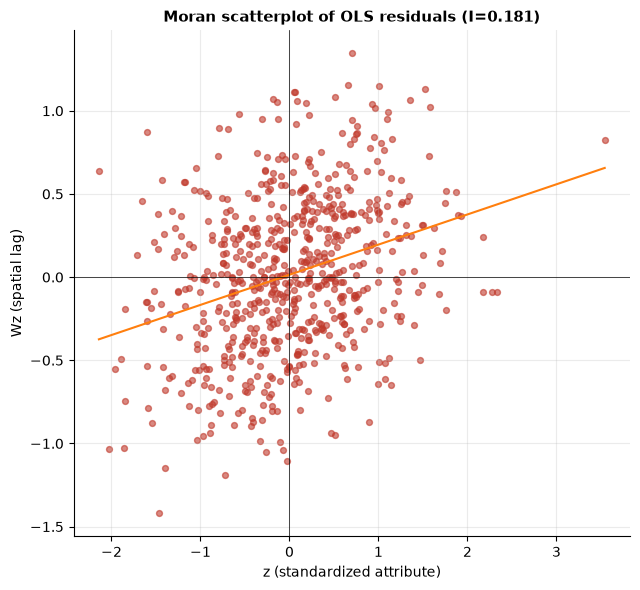

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 6))
res = Moran(ols.residuals, w, permutations=0)  # for the scatterplot geometry only; I already computed exactly above
moran_scatter(res, ax=ax, color=C["red"], alpha=0.6, s=18)
ax.set_title(f"Moran scatterplot of OLS residuals (I={resid_moran['I']:.3f})")
plt.tight_layout()
plt.show()

A clearly positive slope in the residuals — the same visual signature Part 2 used for the raw outcome, now
applied to what a seven-covariate regression could not explain. The next two chapters turn this single number
into a decision between competing spatial models.

***
## 7. Summary and Conclusions

This chapter established the OLS baseline that every later model in Part 3 is compared against.

### What we did

1. Fit `OLS(Dia_pct ~ Obesity + PhysInact + Acc_Exer + PCP_rate + FoodEnvIdx + SVI + Urban, w=w)`: $R^2=0.747$,
   log-likelihood $-784.2$, five of seven covariates significant with expected signs.
2. Clarified exactly what AIC/BIC count in this library (coefficients + spatial parameter, never $\sigma^2$),
   which is what keeps them comparable to the spatial models fitted in later chapters.
3. Ran three classical diagnostics: a moderate condition number (48.1), a mild normality violation
   (Jarque–Bera $p=0.023$), and a strong heteroskedasticity violation (Breusch–Pagan $p\approx 6.7\times
   10^{-10}$).
4. Computed the residual Moran's I with the exact Cliff–Ord moments: $I=0.181$, $z=7.62$, overwhelmingly
   significant — even a strong-fitting model ($R^2=0.747$) leaves a strongly spatially clustered remainder.

### Practical takeaways

- A respectable $R^2$ does not imply independent residuals; always run `residual_moran()`, not just $R^2$,
  before trusting an OLS model's standard errors on spatial data.
- Use the *exact* residual-Moran moments (`residual_moran`/`moran_residuals`), not the raw-variable Moran's I
  formula from Part 2, when testing regression residuals — the reference distribution genuinely differs.
- A significant residual Moran's I alone does not say *which* spatial model to fit; that is Chapter 3.3's job.

### Next steps

**Chapter 3.3 (Model Selection: Spatial Dependence Diagnostics)** takes this same OLS fit and runs the
Lagrange Multiplier tests that formally decide between a spatial lag and a spatial error specification.

***
## 8. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Anselin, L. (1988). *Spatial Econometrics: Methods and Models*. Kluwer Academic. | Origin of the exact residual-Moran moments used in Section 6 |
| Wooldridge, J. M. (2020). *Introductory Econometrics: A Modern Approach* (7th ed.). Cengage. | Standard reference for the classical diagnostics (condition number, JB, BP) |

### Key papers

| Paper | Contribution |
|---|---|
| Cliff, A. D. & Ord, J. K. (1981). *Spatial Processes: Models and Applications*. Pion. | Exact moments of Moran's I for OLS residuals |
| Breusch, T. S. & Pagan, A. R. (1979). A simple test for heteroscedasticity and random coefficient variation. *Econometrica*, 47, 1287–1294. | Origin of the Breusch–Pagan test |
| Jarque, C. M. & Bera, A. K. (1987). A test for normality of observations and regression residuals. *International Statistical Review*, 55, 163–172. | Origin of the Jarque–Bera test |

### In this library

| Object | Role |
|---|---|
| `spatialstats.regression.OLS` | Baseline model; `.summary()`, `.coef_frame()`, `.diagnostics()` |
| `OLS.residual_moran` / `moran_residuals` | Exact Cliff–Ord residual Moran's I |
| `OLS.jarque_bera`, `.breusch_pagan`, `.condition_number` | Classical diagnostics |
| Chapter 3.3 | `lm_tests`, `LMResult.recommendation()` — the formal decision this chapter's residual Moran's I feeds into |